In [52]:
import pandas as pd

DATA = "../data/raw/"

mental_health = pd.read_csv(DATA + "mental_health_trends.csv")
social_usage = pd.read_csv(DATA + "social_media_usage.csv")
screen_time = pd.read_csv(DATA + "screen_time_behavior.csv")
sleep = pd.read_csv(DATA + "sleep_disruption.csv")
dopamine = pd.read_csv(DATA + "dopamine_trigger_metrics.csv")
ai_impact = pd.read_csv(DATA + "ai_recommendation_impact.csv")
cyberbullying = pd.read_csv(DATA + "cyberbullying_impact.csv")
detox = pd.read_csv(DATA + "digital_detox_behavior.csv")
teen = pd.read_csv(DATA + "teen_behavior_patterns.csv")
forecast = pd.read_csv(DATA + "future_psychological_forecast.csv")

print("Archivos cargados correctamente")

Archivos cargados correctamente


In [68]:
print(mental_health.head())
print(mental_health.shape)
print(mental_health.dtypes)
print(mental_health.describe())

   user_id  year       country    age_group  gender   platform  anxiety_score  \
0    23655  2014  Saudi Arabia        Adult  Female  X/Twitter          61.24   
1    15796  2011         Spain  Young Adult    Male  X/Twitter          67.80   
2      861  2035        Brazil       Senior   Other  Instagram          79.80   
3     5391  2034           USA  Young Adult    Male     Reddit          49.41   
4    21576  2059        Mexico  Young Adult   Other     Twitch          84.60   

   depression_score  stress_level  loneliness_index  therapy_access  \
0             33.50         66.03             66.49            True   
1             47.65         72.91             48.61           False   
2             88.73         68.16             49.53           False   
3             48.83         51.07             66.71            True   
4             70.59         50.64             51.14            True   

   medication_usage  self_esteem_score mental_health_risk  
0             False       

In [70]:
cols = ['age_group', 'gender', 'platform', 'mental_health_risk']
for col in cols:
    print(col, ",", mental_health[col]. unique())


print('COLUMNAS DE : mental_health\n')
print(mental_health.columns)

age_group , <StringArray>
['Adult', 'Young Adult', 'Senior', 'Teen', 'Children']
Length: 5, dtype: str
gender , <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
platform , <StringArray>
['X/Twitter', 'Instagram',    'Reddit',    'Twitch',   'YouTube',    'TikTok',
  'LinkedIn',  'Facebook',   'Discord',  'Snapchat']
Length: 10, dtype: str
mental_health_risk , <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
COLUMNAS DE : mental_health

Index(['user_id', 'year', 'country', 'age_group', 'gender', 'platform',
       'anxiety_score', 'depression_score', 'stress_level', 'loneliness_index',
       'therapy_access', 'medication_usage', 'self_esteem_score',
       'mental_health_risk'],
      dtype='str')


In [92]:
mental_health.select_dtypes(include="number").corr()

,user_id,year,anxiety_score,depression_score,stress_level,loneliness_index,self_esteem_score
user_id,1.000000,-0.000927,-0.009751,0.000453,0.000794,0.006794,0.002620
year,-0.000927,1.000000,0.005941,-0.004000,-0.000017,0.004520,-0.011262
anxiety_score,-0.009751,0.005941,1.000000,-0.000075,-0.001272,0.008645,-0.000426
depression_score,0.000453,-0.004000,-0.000075,1.000000,0.004401,-0.013809,-0.002113
stress_level,0.000794,-0.000017,-0.001272,0.004401,1.000000,-0.003591,0.000965
loneliness_index,0.006794,0.004520,0.008645,-0.013809,-0.003591,1.000000,0.002936
self_esteem_score,0.002620,-0.011262,-0.000426,-0.002113,0.000965,0.002936,1.000000


<Axes: xlabel='depression_score', ylabel='stress_level'>

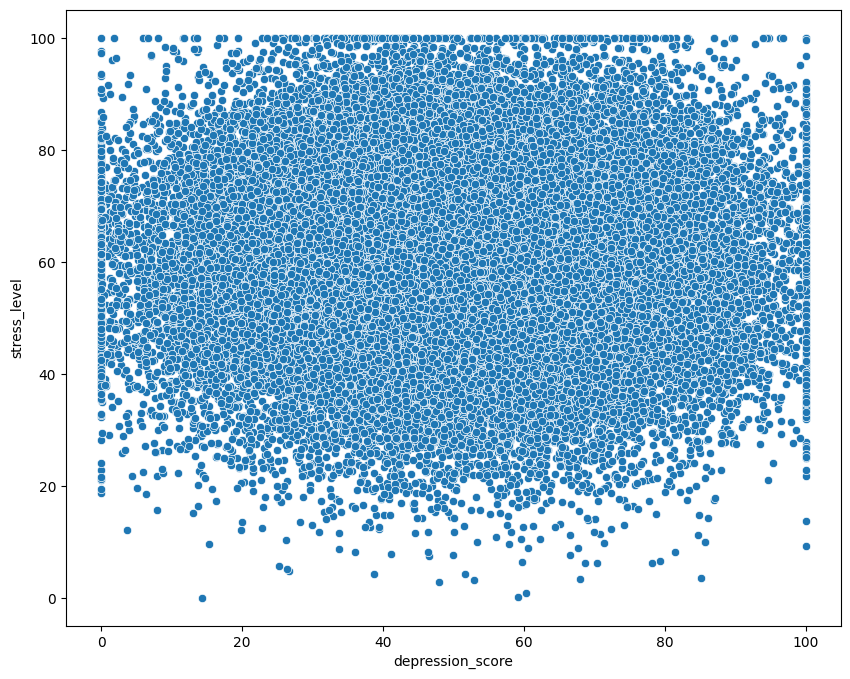

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,8))
sns.scatterplot(data = mental_health, x = 'depression_score',y =  'stress_level')

Pregunta 1: ¿Qué grupo de edad tiene mayor depression_score promedio?

In [71]:
depression_por_edad = mental_health.groupby('age_group')['depression_score'].mean().sort_values(ascending= False)
print(depression_por_edad)

age_group
Children       50.279733
Adult          50.061549
Young Adult    49.960548
Teen           49.856309
Senior         49.561388
Name: depression_score, dtype: float64


In [78]:
mental_health.groupby("age_group")["depression_score"].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
Adult,9985.0,50.061549,19.543115,0.0,36.760,49.91,63.400,100.0
Children,10017.0,50.279733,19.724178,0.0,36.640,50.30,63.540,100.0
Senior,9931.0,49.561388,19.995330,0.0,36.115,49.50,63.200,100.0
Teen,10071.0,49.856309,19.778306,0.0,36.490,49.57,63.195,100.0
Young Adult,9996.0,49.960548,19.694269,0.0,36.265,50.02,63.460,100.0


Pregunta 2: ¿Qué plataforma se asocia con mayor depresión?

In [82]:
depresion_por_plataforma = mental_health.groupby('platform')['depression_score'].mean().sort_values(ascending=False)
print(depresion_por_plataforma)
print(mental_health.groupby('platform')['depression_score'].describe())

platform
Twitch       50.279573
TikTok       50.216346
Snapchat     50.164761
LinkedIn     49.972799
X/Twitter    49.958643
Reddit       49.951396
Instagram    49.844820
Facebook     49.829978
YouTube      49.666532
Discord      49.568499
Name: depression_score, dtype: float64
            count       mean        std  min      25%     50%      75%    max
platform                                                                     
Discord    4991.0  49.568499  19.746361  0.0  36.1850  49.220  62.8600  100.0
Facebook   4996.0  49.829978  19.898452  0.0  36.3125  50.050  63.3325  100.0
Instagram  4992.0  49.844820  19.612268  0.0  36.4500  50.010  63.4175  100.0
LinkedIn   5038.0  49.972799  19.646203  0.0  36.1900  49.935  63.5475  100.0
Reddit     5016.0  49.951396  19.748853  0.0  36.6925  50.010  63.2350  100.0
Snapchat   5007.0  50.164761  19.768631  0.0  36.6300  50.000  63.4900  100.0
TikTok     4984.0  50.216346  19.700927  0.0  36.7000  49.800  63.5000  100.0
Twitch     4894.0  5

In [ ]:
print(cyberbullying.head())
print(cyberbullying.describe())

In [89]:
cyberbullying.columns

Index(['user_id', 'year', 'country', 'age_group', 'gender', 'platform',
       'cyberbullying_exposure', 'harassment_frequency',
       'self_harm_risk_score', 'social_withdrawal_score',
       'reported_to_authorities'],
      dtype='str')

¿Los usuarios expuestos a cyberbullying tienen mayor self_harm_risk_score y social_withdrawal_score?

In [91]:
cyber_grupo = cyberbullying.groupby('cyberbullying_exposure')[['self_harm_risk_score', 'social_withdrawal_score']].mean()
print(cyber_grupo)

                        self_harm_risk_score  social_withdrawal_score
cyberbullying_exposure                                               
False                              50.126405                50.037029
True                               49.876530                49.958355
